# Evaluation of GGUF Model

Model name: **SmolVLM-256M-Instruct-GGUF**

## Start the server first with

```bash
llama-server -hf ggml-org/SmolVLM-256M-Instruct-GGUF -ngl 99 --threads-http 8 -np 8 -c 32768
```

In [1]:
import base64
import requests
import os
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import time

In [2]:
import re, json
df = pd.read_csv('../fire_captions_combined.csv')
print(f"Total samples in dataset: {len(df)}")
df.head()

Total samples in dataset: 2145


,image_path,label,caption
0,fire_dataset_combined/image1.jpg,no fire,The image shows a cozy living room with a fire...
1,fire_dataset_combined/image2.jpg,no fire,The image shows a neatly arranged bedroom with...
2,fire_dataset_combined/image3.jpg,no fire,The image shows a dining area with a wooden ta...
3,fire_dataset_combined/image4.jpg,no fire,The image shows a modern office space with lar...
4,fire_dataset_combined/image5.jpg,no fire,The image shows a hospital room with a patient...


In [9]:
def process_image(image_path):
    """Process a single image and return the model's prediction, caption and inference time"""
    try:
        # Start timing
        start_time = time.time()

        # Load image
        with open(image_path, "rb") as f:
            base64_bytes = base64.b64encode(f.read()).decode("utf-8")
        data_url = f"data:image/jpeg;base64,{base64_bytes}"

        # Fire analysis prompt
        prompt = (
            "You are a visual analyst evaluating an image for signs of fire and the surrounding context. "
            "Do the following tasks:\n"
            "1: Summarize what you see in the image. Describe the environment, key objects, people, and any signs of fire or smoke.\n"
            "2: Based on your summary, classify the fire situation: "
            "no fire(e.g., fire alarm, fire distinguisher, fireplace with no fire burning inside..), controlled fire (e.g., fireplace with a fire burning inside, campfire, cooking, candles, match stick, lighter..) or a dangerous/uncontrolled fire (e.g., curtains on fire, smoke on ceiling, couch on fire, bed sheet on fire, spreading fire on furniture..)?\n"
            "Return only this JSON format:\n"
            "{ \"caption\": \"...\", \"label\": \"no fire\"|\"controlled fire\"|\"dangerous fire\" }"
        )

        # Compose JSON payload
        payload = {
            "max_tokens": 500,
            "messages": [
                {
                    "role": "system",
                    "content": prompt
                },
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": data_url
                            }
                        }
                    ]
                }
            ]
        }


        # Send to llama-server
        response = requests.post("http://127.0.0.1:8080/v1/chat/completions", json=payload)
        # print(response.json())
        content = response.json()["choices"][0]["message"]["content"]
        json_str = re.sub(r"^```json|```$", "", content.strip(), flags=re.MULTILINE).strip()
        result = json.loads(json_str)
        label = result['label']
        caption = result['caption']

        # Calculate inference time
        inference_time = time.time() - start_time

        return label, caption, inference_time

    except Exception as e:
        print(f"Error processing {image_path}: {str(e)}")
        return "error", "", 0.0

In [10]:
# Process all images and collect predictions
predictions = []
captions = []
inference_times = []
ground_truth = []

for idx, row in df.iterrows():
    img_path = os.path.join('../',row['image_path'])
    if os.path.exists(img_path):
        pred, caption, inf_time = process_image(img_path)
        predictions.append(pred)
        captions.append(caption)
        inference_times.append(inf_time)
        ground_truth.append(row['label'])
        # print(f"{img_path}: {pred}, truth: {row['label']}, caption: {caption}")
        if idx % 10 == 0:
            print(f"Processed {idx} images... Average inference time so far: {np.mean(inference_times):.3f}s")

print(f"\nProcessing complete! Average inference time: {np.mean(inference_times):.3f}s")

KeyboardInterrupt: 

In [6]:
# Calculate metrics
accuracy = accuracy_score(ground_truth, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(
    ground_truth,
    predictions,
    average='weighted'
)

print("Model Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"\nInference Time Statistics:")
print(f"Average: {np.mean(inference_times):.3f}s")
print(f"Std Dev: {np.std(inference_times):.3f}s")
print(f"Min: {np.min(inference_times):.3f}s")
print(f"Max: {np.max(inference_times):.3f}s")

Model Performance Metrics:
Accuracy: 0.9287
Precision: 0.9449
Recall: 0.9287
F1 Score: 0.9323

Inference Time Statistics:
Average: 4.026s
Std Dev: 0.350s
Min: 3.021s
Max: 5.305s


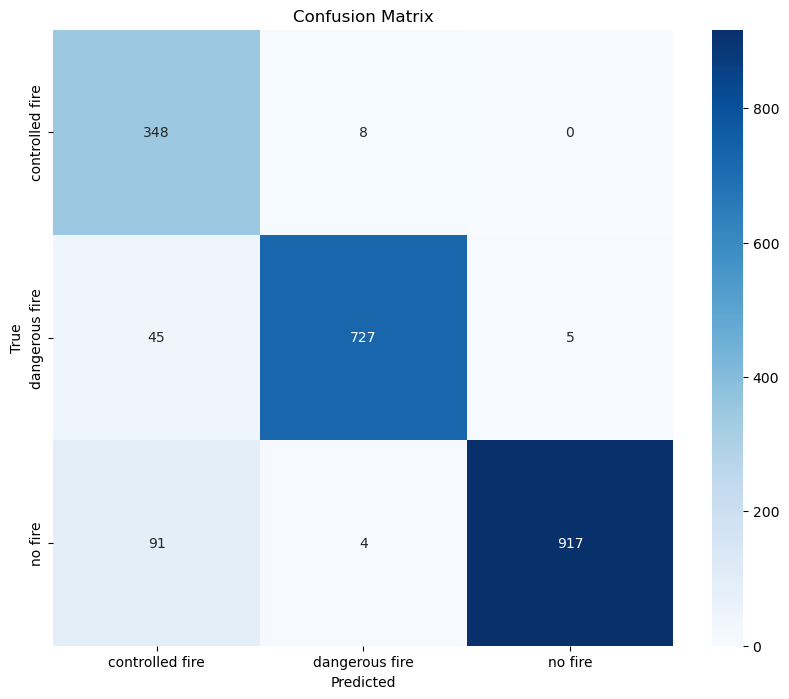

In [7]:

# Create and plot confusion matrix
labels = sorted(list(set(ground_truth)))
cm = confusion_matrix(ground_truth, predictions, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [8]:
# Save results to CSV
results_df = pd.DataFrame({
    'image_path': df['image_path'],
    'true_label': ground_truth,
    'predicted_label': predictions,
    'caption': captions,
    'inference_time': inference_times,
    'correct': [t == p for t, p in zip(ground_truth, predictions)]
})

results_df.to_csv('gemma3_4B_IT_GGUF_results.csv', index=False)
print("Results saved to gemma3_4B_IT_GGUF_results.csv")

Results saved to gemma3_4B_IT_GGUF_results.csv


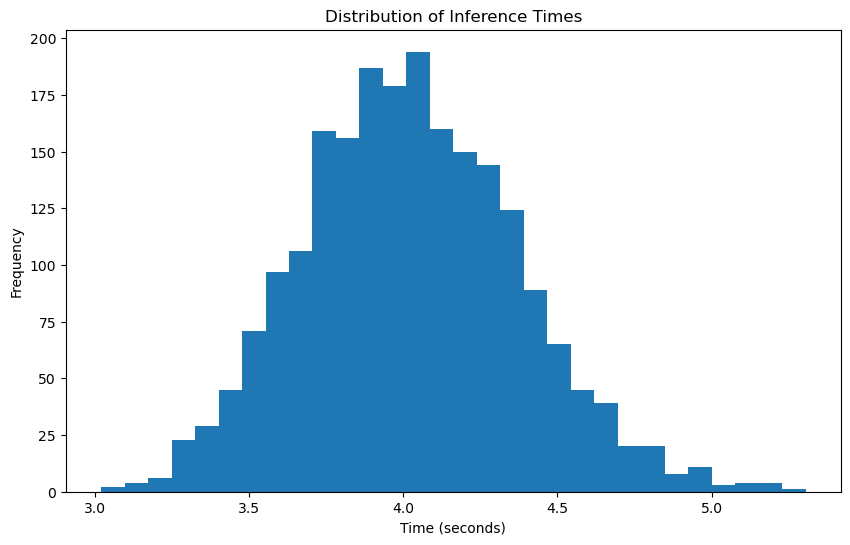

In [9]:

# Display inference time distribution
plt.figure(figsize=(10, 6))
plt.hist(inference_times, bins=30)
plt.title('Distribution of Inference Times')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.show()